In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

df1 = pd.read_json("/content/test_dataset.json")
df2 = pd.read_json("/content/train_dataset.json")
df3 = pd.read_json("/content/val_dataset.json")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Creamos una matriz con los valores posibles (diferentes en cada instancoa)

valores = []
columns = []

for col in df2.columns:
    columns.append(col)
    val = []
    for value in df2[col]:
        if isinstance(value, int) or isinstance(value, float):
            break

        if value in val:
            continue
        else:
            val.append(value)

    valores.append(val)

#Nos enfocamos especialmente en los valores posibles en 'communications'

tipos = valores[1]

valores_posibles = []

for lista in tipos:
    if isinstance(lista, list):
        for val in lista:
            if val in valores_posibles:
                continue
            else:
                valores_posibles.append(val)
    else:
        continue

In [ ]:
#Cambios a las instancias

def f1(s):
    if s == "dedicated graphics":
        return 1

    elif s == "integrated graphics":
        return 2

    else:
        return 0

#Cambio  a la instancia 'resolution (px)'

def f2(s):
    if isinstance(s, str) == False or s == "other":
        return 0

    else:
        a = int(s[0:4])
        b = int(s[7:len(s)])
        res = a*b

        return res

#Cambio a la instancia 'CPU cores'

def f3(s):
    if s == "not applicable":
        return 0
    else:
        return int(s)


#Cambio a la instancia 'RAM size'

def f4(s):
    if isinstance(s, str):
        return int(s.replace(" gb",""))
    else:
        return 0

#Cambio a la instancia 'operating system'

def f5(s):
    tipo = ["windows 7", "windows 8", "windows 10"]

    if isinstance(s, list):
        contador = 0
        for elemento in s:
            for so in tipo:
                if so in elemento:
                    contador += tipo.index(so) + 2
                    #return tipo.index(so) + 2
        if contador > 0:
            return contador
        else:
            return 1

    else:
        return 0



#Cambio a la instancia 'drive type'

def f6(s):
    tipo = ["ssd + hdd", "ssd", "hdd", "emmc", "hybrid"]
    if isinstance(s, str):
        return tipo.index(s) + 1
        #return tipo.index(s) + 1 if s in tipo else 0
        #evitar errores si el valor no está en la lista
    else:
        return 0


#Cambio a la instancia 'input devices' y 'multimedia'

def f7(s):
    if isinstance(s, list):
        return len(s)
    else:
        return 0


#Cambio a la instancia 'RAM type'

def f8(s):
    tipo = ["ddr4", "ddr3", "ddr3l"]
    if isinstance(s, str):
        return tipo.index(s) + 1
    else:
        return 0

#Cambio a la instancia 'warranty'

def f9(s):
    tipo = ["producer warranty", "seller warranty", "no warranty"]
    if isinstance(s, str):
        return tipo.index(s) + 1
    else:
        return 0

#Cambio a la instancia 'screen size'

def f10(s):
    if isinstance(s, str):
        if "less" in s:
            return 180
        else:
            a = float(s[0:2])
            b = float(s[6:len(s)-1])
            return a*b
    else:
        return 0


#Cambio a la instancia 'CPU model'

def f11(s):
    tipo = ['intel core i7', 'other CPU', 'intel core i3',
            'intel core i5', 'intel celeron dual-core',
            'intel pentium 4', 'intel celeron quad core ',
            'amd a6', 'intel celeron ', 'intel pentium dual-core',
            'amd a12', 'amd a8', 'intel pentium quad-core ',
            'intel core m', 'amd a4', 'intel celeron m', 'amd a10',
            'amd e1']

    if isinstance(s, str):
        return tipo.index(s) + 1
    else:
        return 0

#Cambio a la instancia 'communications'

def f12(s):
    if isinstance(s, list):
        contador = 0
        for tipo in valores_posibles:
            if tipo in s:
                contador += s.index(tipo) + 1
        return contador
    else:
        return 0


In [ ]:
cambio = {
    "graphic card type": f1,
    "resolution (px)": f2,
    "CPU cores": f3,
    "RAM size": f4,
    "operating system": f5,
    "drive type": f6,
    "input devices": f7,
    "multimedia": f7,
    "RAM type": f8,
    "warranty": f9,
    "screen size": f10,
    "CPU model": f11,
    "communications": f12
}



for df in [df1, df2]:
    for col, func in cambio.items():
        df[col] = df[col].apply(func)



In [ ]:
# Ganancias de informacion
# Falta incluir atributo communications
train_df = pd.read_json("/content/test_dataset.json")
val_df = pd.read_json("/content/train_dataset.json")
test_df = pd.read_json("/content/val_dataset.json")

target = 'buynow_price'

numerical_cols = ['CPU clock speed (GHz)', 'drive memory size (GB)']
categorical_cols = ['screen size', 'warranty', 'RAM size', 'CPU cores', 'resolution (px)', 'graphic card type', 'drive type', 'RAM type', 'CPU model', 'state']
multi_label_cols = ['communications']  # 'operating system', 'communications', 'multimedia']

train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

df = pd.concat([train_df, val_df, test_df], ignore_index=True)

train_df = df[df['split'] == 'train'].drop(columns=['split'])
val_df = df[df['split'] == 'val'].drop(columns=['split'])
test_df = df[df['split'] == 'test'].drop(columns=['split'])

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_val = val_df.drop(columns=[target])
y_val = val_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

X_train['communications'] = X_train['communications'].apply(lambda x: x if isinstance(x, list) else [])
X_val['communications'] = X_val['communications'].apply(lambda x: x if isinstance(x, list) else [])
X_test['communications'] = X_test['communications'].apply(lambda x: x if isinstance(x, list) else [])

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin): #función usada para convertir cada elemento de atributos con listas en atributos binarios
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self

    def transform(self, X):
        return self.mlb.transform(X)

    def fit_transform(self, X, y=None):
        return self.mlb.fit_transform(X)

    def get_params(self, deep=True):
        return {}

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols),
        ('mlb_comm', MultiLabelBinarizerTransformer(), 'communications'),  # Tratamiento adecuado para 'communications'
    ]
)

#  Modelo XGB
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1, 0.2]
}

random_search = RandomizedSearchCV(xgb_model, param_grid, n_iter=5, cv=3, scoring='neg_mean_absolute_error', verbose=1)
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Calcular importancia
importancias = best_model.named_steps['regressor'].feature_importances_
atributos = numerical_cols + categorical_cols
cat_columns_transformed = best_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_cols)
atributos.extend(cat_columns_transformed)

if len(atributos) != len(importancias):
    n_missing = len(importancias) - len(atributos)
    atributos.extend([f"Extra_{i}" for i in range(n_missing)])

importancia_df = pd.DataFrame({'Atributo': atributos, 'Importancia': importancias})
importancia_df = importancia_df.sort_values(by='Importancia', ascending=False)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(importancia_df) #importancia por cada atributo


# Resultado inicial sin considerar importancia o cambio de instancias
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape:.2f}%")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
                                 Atributo  Importancia
29                          RAM size_6 gb     0.135778
23                         RAM size_16 gb     0.088346
79     CPU model_intel pentium quad-core      0.063913
17                screen size_17" - 17.9"     0.056003
65                      CPU model_amd a12     0.049810
27                         RAM size_32 gb     0.048881
45            resolution (px)_2560 x 1440     0.045230
38             resolution (px)_1280 x 800     0.043234
18                       screen size_None     0.037825
0                   CPU clock speed (GHz)     0.033693
33                            CPU cores_2     0.031015
13                screen size_12" - 12.9"     0.029992
35                            CPU cores_4     0.029785
2                             screen size     0.023067
42            resolution (px)_1920 x 1200     0.022431
47            resolution (px)_3200 x 1800     0.021089
64   

In [ ]:
x_train = df2.drop(columns=["buynow_price","state"])
y_train = df2["buynow_price"]

x_test = df1.drop(columns=["buynow_price","state"])
y_test = df1["buynow_price"]

#saber si hay valores nulos
#print(x_train.isnull().sum())
#verificar tipos de datos
#print(x_train.dtypes)

# Entrenar modelo
model = XGBRegressor(n_estimators=100, learning_rate=0.1)
model.fit(x_train, y_train)

# Predicciones y métricas
y_pred = model.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape:.2f}%") #puede ser inestable si hay valores pequeños en y_test

RMSE: 746.0059126147298
MAE: 423.876456563793
MAPE: 13.06%


In [ ]:
#para entrenar el modelo:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

random_search = RandomizedSearchCV(XGBRegressor(), param_grid, n_iter=5, cv=3, scoring='neg_mean_absolute_error', verbose=1)
random_search.fit(x_train, y_train)

best_model = random_search.best_estimator_
y_pred = best_model.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(y_pred)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape:.2f}%")


Fitting 3 folds for each of 5 candidates, totalling 15 fits
[2445.753  2329.3042 5330.849  ... 7086.4346 3805.6587 1487.8046]
RMSE: 730.6173592677496
MAE: 391.321401115432
MAPE: 11.98%


In [ ]:
#ganancias de informacion
importancias = best_model.feature_importances_
atributos = x_train.columns

importancia_df = pd.DataFrame({'Atributo': atributos, 'Importancia': importancias})
importancia_df = importancia_df.sort_values(by='Importancia', ascending=False)

print(importancia_df)


                  Atributo  Importancia
3                CPU cores     0.221157
10   CPU clock speed (GHz)     0.195907
2          resolution (px)     0.132029
4                 RAM size     0.072036
9                 RAM type     0.065308
14             screen size     0.062372
8               multimedia     0.054935
11               CPU model     0.043658
6               drive type     0.041071
0        graphic card type     0.025895
13                warranty     0.025846
7            input devices     0.018991
12  drive memory size (GB)     0.018511
5         operating system     0.011614
1           communications     0.010669


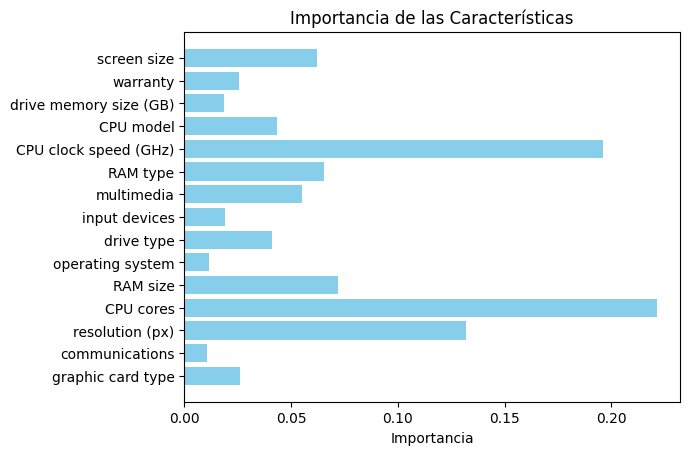

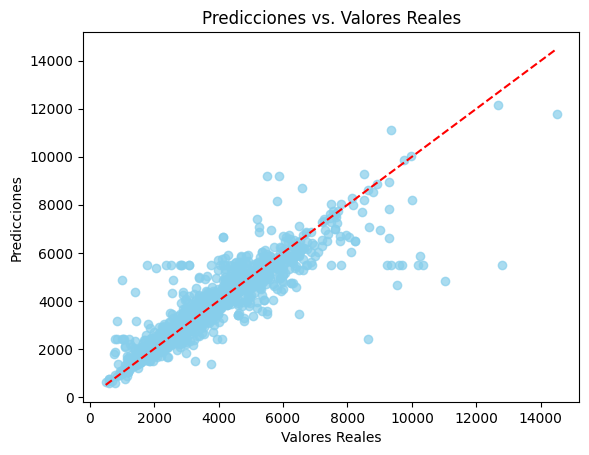

In [ ]:
#gráficas

#ganancia de informacion
plt.barh(x_train.columns, importancias, color='skyblue')
plt.xlabel('Importancia')
plt.title('Importancia de las Características')
plt.show()

#reales vs prediccion
plt.scatter(y_test, y_pred, color='skyblue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs. Valores Reales')
plt.show()